# 🏠 MietCheck – Zahle ich zu viel Miete?
### Data-Science-Analyse entlang des QUA³CK-Prozessmodells

**Modul:** Data Analytics & Big Data (IU, 4. Semester)  
**Fragestellung:** Lässt sich aus wenigen, für jeden Laien verständlichen Angaben eine *faire Kaltmiete* vorhersagen – und daraus ein Alltagswerkzeug bauen?

**USP:** Miete betrifft alle. MietCheck gibt in Sekunden einen datenbasierten Richtwert und ein klares Urteil: *Schnäppchen · Fair · Zu teuer.*

| Phase | Inhalt |
|---|---|
| **Q** Qualitätsprüfung | Ausreißer & Fehler entfernen |
| **U** Understanding the Data | Explorative Datenanalyse (EDA) |
| **A** Algorithmenauswahl + Modellentwicklung | Pipeline & Modellvergleich |
| **C** Kreuzvalidierung | faire Modellauswahl |
| **K** Wissensextraktion | Merkmalswichtigkeit & App |

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Projekt-Root in den Pfad legen, damit src-Module importierbar sind
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import config as C
sns.set_theme(style='whitegrid', palette='rocket')
print('Setup ok · Root:', ROOT)

Setup ok · Root: /Users/soufianefed/Desktop/MietCheck


## Q — Qualitätsprüfung
Zuerst prüfen wir Datenqualität: Wie viele Werte fehlen, und welche Werte sind unplausibel?

In [2]:
raw = pd.read_csv(C.RAW_CSV, low_memory=False)
print(f'Rohdaten: {raw.shape[0]:,} Zeilen × {raw.shape[1]} Spalten')

# Fehlende Werte der für uns relevanten Merkmale
cols = [c for c in C.FEATURES + [C.TARGET] if c in raw.columns]
miss = (raw[cols].isna().mean() * 100).round(1).sort_values(ascending=False)
miss.to_frame('fehlend_%')

Rohdaten: 268,850 Zeilen × 49 Spalten


,fehlend_%
interiorQual,41.9
condition,25.5
yearConstructed,21.2
typeOfFlat,13.6
livingSpace,0.0
noRooms,0.0
regio1,0.0
regio2,0.0
balcony,0.0
hasKitchen,0.0


In [3]:
# Warum eine Qualitätsprüfung nötig ist: die Zielgröße enthält groben Unsinn
print('Kaltmiete roh – min/median/max:')
print(raw[C.TARGET].agg(['min','median','max']).round(0).to_string())
print('\n=> Werte von 0 € bis 9.999.999 € sind Datenfehler und müssen raus.')

Kaltmiete roh – min/median/max:
min             0.0
median        490.0
max       9999999.0

=> Werte von 0 € bis 9.999.999 € sind Datenfehler und müssen raus.


In [4]:
# Bereinigung anwenden (identische Logik wie in src/data_prep.py)
from data_prep import quality_check
df = quality_check(raw)
print(f'\nBereinigt: {len(df):,} Zeilen · Kaltmiete jetzt '
      f"{df[C.TARGET].min():.0f}–{df[C.TARGET].max():.0f} €")

→ Qualitaetspruefung: 268,850 → 202,908 Zeilen (24.5 % entfernt)

Bereinigt: 202,908 Zeilen · Kaltmiete jetzt 100–6000 €


## U — Understanding the Data (EDA)
Jetzt verstehen wir die Struktur der Daten: Verteilung der Miete, regionale Unterschiede und Zusammenhänge.

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[C.TARGET], bins=60, ax=ax[0], color='#b5179e')
ax[0].set(title='Kaltmiete (€) – rechtsschief', xlabel='Kaltmiete')
sns.histplot(np.log1p(df[C.TARGET]), bins=60, ax=ax[1], color='#7209b7')
ax[1].set(title='Kaltmiete log-transformiert – annähernd normal', xlabel='log(1+Miete)')
plt.tight_layout(); plt.show()

In [6]:
# Der Kern des USP: Miete pro m² unterscheidet sich massiv nach Region
df = df.assign(eur_sqm=df[C.TARGET] / df['livingSpace'])
order = df.groupby('regio1')['eur_sqm'].median().sort_values(ascending=False).index
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='regio1', y='eur_sqm', order=order, showfliers=False)
plt.xticks(rotation=60); plt.ylabel('€ / m²'); plt.xlabel('')
plt.title('Kaltmiete pro m² nach Bundesland'); plt.tight_layout(); plt.show()

In [7]:
# Zusammenhänge der numerischen Merkmale
num = df[C.NUMERIC_FEATURES + [C.TARGET, 'eur_sqm']]
plt.figure(figsize=(7, 5))
sns.heatmap(num.corr(), annot=True, fmt='.2f', cmap='rocket_r')
plt.title('Korrelationsmatrix'); plt.tight_layout(); plt.show()
print('Wohnfläche korreliert am stärksten mit der Miete – erwartbar.')

Wohnfläche korreliert am stärksten mit der Miete – erwartbar.


## A — Algorithmenauswahl & Modellentwicklung
Die Datenaufbereitung steckt als wiederverwendbare **sklearn-Pipeline** im Modell:
Imputation fehlender Werte → Standardisierung numerischer Merkmale → One-Hot-Encoding der Kategorien.
Verglichen werden drei Algorithmen aus der Vorlesung.

In [8]:
from train import build_preprocessor
pre = build_preprocessor()
pre  # Struktur der Aufbereitungs-Pipeline anzeigen

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['livingSpace', 'noRooms', 'yearConstructed']),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=30,
                                                                sparse_output=False))]),
                                 ['regio1', 'regio2', 'condition',
                                  'interiorQual', 'typeOfFlat']),
                                ('bool', 'passthrough',
                                 ['balcony', 'hasKitchen', 'cellar', 'lift',
                                  'garden', 'newlyConst'])])

## C — Kreuzvalidierung
Die 5-fache Kreuzvalidierung (in `src/train.py` ausgeführt) vergleicht die Modelle fair.
Wir laden die gespeicherten Kennzahlen.

In [9]:
metrics = json.loads((C.REPORT_DIR / 'metrics.json').read_text())
cv = pd.DataFrame(metrics['cv_results']).T[['cv_mae']].round(1)
cv.columns = ['CV-MAE (€)']
print('Bestes Modell:', metrics['best_model'])
print(f"Test-MAE: {metrics['test_mae']} € · R²: {metrics['test_r2']} · MAPE: {metrics['test_mape']} %")
cv.sort_values('CV-MAE (€)')

Bestes Modell: Gradient Boosting
Test-MAE: 89.7 € · R²: 0.898 · MAPE: 13.7 %


,CV-MAE (€)
Gradient Boosting,90.2
Random Forest,102.7
Lineare Regression,120.5


## K — Wissensextraktion
Welche Merkmale treiben den Preis? Und wie gut trifft das Modell?

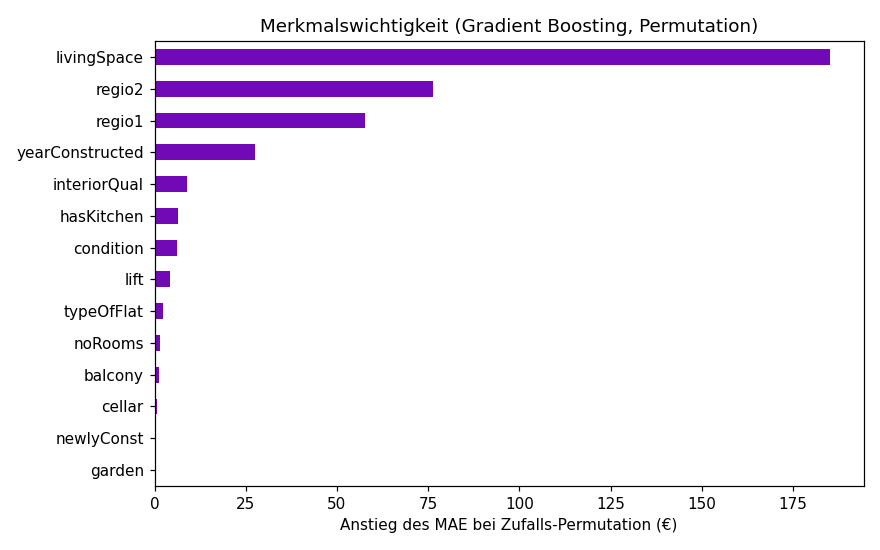

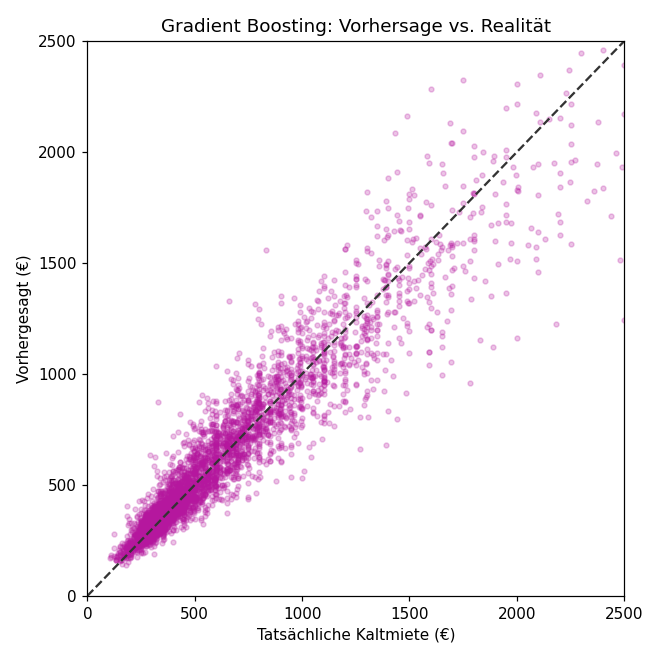

In [10]:
from IPython.display import Image, display
for img in ['06_merkmalswichtigkeit.png', '05_pred_vs_real.png']:
    p = C.REPORT_DIR / img
    if p.exists():
        display(Image(str(p)))

In [11]:
# Das trainierte Modell direkt ausprobieren
from joblib import load
model = load(C.MODEL_FILE)
beispiel = pd.DataFrame([{ 'livingSpace': 70, 'noRooms': 2.0, 'yearConstructed': 1990,
    'regio1': 'Berlin', 'regio2': 'Berlin', 'condition': 'well_kept',
    'interiorQual': 'normal', 'typeOfFlat': 'apartment', 'balcony': True,
    'hasKitchen': True, 'cellar': False, 'lift': False, 'garden': False,
    'newlyConst': False }])
print(f'Faire Kaltmiete (70 m², Berlin): {model.predict(beispiel)[0]:.0f} €')

Faire Kaltmiete (70 m², Berlin): 694 €


## Fazit
- Aus **wenigen, laienverständlichen Angaben** lässt sich die faire Kaltmiete mit **± ~90 € (R² ≈ 0,90)** vorhersagen.
- Wichtigste Preistreiber: **Wohnfläche, Stadt, Bundesland**.
- Das Modell wird als **Streamlit-App** ausgeliefert (`streamlit run app.py`) – der USP für Alltagsuser: *„Zahle ich zu viel Miete?“* mit klarem Urteil.

**Grenzen:** Richtwert auf Basis historischer Angebote, kein amtlicher Mietspiegel; sehr seltene Orte/Extremwohnungen werden schlechter getroffen.